# data processing
for ruiyi data structure

## imports

In [1193]:
%reload_ext autoreload
%autoreload 2

In [1194]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [1195]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


In [1196]:
# misc
import pickle
from collections import defaultdict

In [1197]:
# task
from env_config import Config
from firefly_task import ffacc_real
# from monkey_functions import *
# from InverseFuncs import *
from stable_baselines3 import TD3
import torch


In [1198]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# Pre IRC

convert the mat data file (with neural data) into (states, actions, tasks) for IRC.


## prepare

In [1199]:
# const
vgain = 200 # forward gain, 200 cm
wgain = 90 # angular gain, 90 degreea# const
bin_size = 1  # how many bin of DT
# num_bins = 24  # how many bins to use. use 2.4 s and discard the long trials.
# monkey_height = 10
DT = 0.006  # DT for raw data
# reward_boundary = 65
areas = ['PPC', 'PFC', 'MST']
worldscale = 200


m = 'm51'
folder = 'm51_mat_ruiyi'
dens = [0.0001, 0.0005, 0.001,  0.005]

locals().update({m: {}})
figure_path = resdir/'figures'
# datapaths = [i for i in Pa1th(resdir/'mat_ruiyi').glob(f'{m}*.mat')]
datapaths = [i for i in Path(resdir/folder).glob(f'{m}*.mat')]
session=[int(a.stem[-2:]) for a in datapaths]

worldscale=200


## from ruiyi data file

In [1200]:
# load 
file=Path(Path(resdir/'variable_data_test.pkl'))
df=pd.read_pickle(file)
df=df.iloc[:100]

In [1201]:
m = 'm51'
session=df.sess_id.unique()
session

array(['s38'], dtype=object)

## IRC input data (state, action, task)

In [1202]:
sessdata=defaultdict(list)

for sess in session:
    states, actions, tasks=[],[],[]
    sessdf=df[df.sess_id==sess]
    trial_idces=sessdf.trial_idx

    for trial_idx in trial_idces:
        trialdf=sessdf[sessdf.trial_idx==trial_idx]
        trialdata=trialdf.iloc[0]
        # task
        taskx = -(trialdata.tar_x - trialdata.mx[0]).astype('float32'); tasky = (trialdata.tar_y - trialdata.my[0]).astype('float32')
        tasks.append([tasky/worldscale,taskx/worldscale])
        # actions
        trialaction=np.stack([trialdata.mv,trialdata.mw]).T
        trialaction[:,0]=trialaction[:,0]/vgain
        trialaction[:,1]=trialaction[:,1]/wgain
        actions.append(trialaction.astype('float32'))

        # states from run the actions
        px, py, heading, v, w = 0,0,0,0,0
        log=[]
        for a in trialaction:
            px, py, heading, v, w=state_step2(px, py, heading, v, w, a, dt=0.006,userad=True)
            log.append([px, py, heading, v, w])
        px, py, heading, v, w=state_step2(px, py, heading, v, w, a, dt=0.006,userad=True)
        log.append([px, py, heading, v, w])
        trialstates=np.array(log)[1:]
        # plt.plot(trialstates[:,0],trialstates[:,1])
        # plt.scatter(tasky/worldscale,taskx/worldscale)
        # plt.plot(trialdata.my, trialdata.mx);plt.show()
        # plt.plot(trialdata.body_theta_ds-pi/2)
        # plt.plot(np.cumsum(trialstates[:,4])*0.1)
        # plt.plot(trialstates[:,2]);plt.show()
        states.append(trialstates.astype('float32'))

        sessdata['sess_id'].append(sess)
        sessdata['trial_idx'].append(trial_idx)
        sessdata['state'].append(trialstates.astype('float32'))  
        sessdata['action'].append(trialaction.astype('float32'))  
        sessdata['task'].append([tasky/worldscale,taskx/worldscale])  

tmp=pd.DataFrame(sessdata)
df = pd.merge(df, tmp, on=['trial_idx','sess_id'], how='inner')

## Compute belief 

In [1203]:
# model estimated likelihood (negative log likelihood)
torch.manual_seed(42)
arg = Config()

env = ffacc_real.FireFlyPaper(arg)
env.debug=True
env.dt=0.006
phi = torch.tensor([[1],
                    [pi/2],
                    [0.001],
                    [0.001],
                    [0.001],
                    [0.001],
                    [0.001],
                    [0.001],
                    [0.001],
                    [0.001],
                    [0.001],
                    ])

agent_ = TD3.load(workdir/'trained_agent/paper')
agent = agent_.actor.mu.cpu()

In [1204]:
thetas={}
for idensity in range(4):
    datapath = Path(resdir/f'{m}_mat_ruiyi/preirc_den_{idensity}')
    savename = datapath.parent/(f'{m}_{idensity}'+datapath.name)
    invfile=savename
    print(datapath.name)
    finaltheta, finalcov, err = process_inv(
        invfile, removegr=False, usingbest=False)
    
    finaltheta[0]=1.2
    finaltheta[1]=pi/2-0.3
    # finaltheta[1]=1.3
    # finaltheta[1]=0.5
    finaltheta[6]=0.001 # set goal radius to zero.
    print(finaltheta[:4])
    thetas[idensity]=finaltheta


preirc_den_0
/Users/yc/Documents/lab_data/m51_mat_ruiyi/m51_0preirc_den_0
using ind:  -1 final logll :  16.993248803274973
tensor([[1.2000],
        [1.2708],
        [0.7104],
        [0.1499]])
preirc_den_1
/Users/yc/Documents/lab_data/m51_mat_ruiyi/m51_1preirc_den_1
using ind:  -1 final logll :  15.665690626416888
tensor([[1.2000],
        [1.2708],
        [0.6041],
        [0.1469]])
preirc_den_2
/Users/yc/Documents/lab_data/m51_mat_ruiyi/m51_2preirc_den_2
using ind:  -1 final logll :  16.006959642682755
tensor([[1.2000],
        [1.2708],
        [0.5796],
        [0.1894]])
preirc_den_3
/Users/yc/Documents/lab_data/m51_mat_ruiyi/m51_3preirc_den_3
using ind:  -1 final logll :  15.557111876351494
tensor([[1.2000],
        [1.2708],
        [0.5519],
        [0.1930]])


In [1205]:
denslookup={0.0001:0, 0.0005:1, 0.001:2,  0.005:3}
thisdensity=trialdf.density.item()
denslookup[thisdensity],thisdensity

(2, 0.001)

In [1206]:
# df belief

def lltrial(state, action, task, finaltheta, samples=5):
    with torch.no_grad():
        return monkeyloss_(agent, action, np.array(task).reshape(1,-1), phi, finaltheta, env, action_var=0.01, num_iteration=1, states=state, samples=samples, gpu=False).item()

belief_df=defaultdict(list)

for sess in session:
    sessdf=df[df.sess_id==sess]
    state, action, task = df.state.to_list(), df.action.to_list(),df.task.to_list()
    trial_idces=sessdf.trial_idx
    for trial_idx in trial_idces:
        trialdf=sessdf[sessdf.trial_idx==trial_idx]
        trialdata=trialdf.iloc[0]
        state, action, task = trialdata.state, trialdata.action, trialdata.task
        thisdensity=trialdf.density.item()
        theta=thetas[denslookup[thisdensity]]

        _, _, ep_belief, ep_rawcov = run_trials(agent=agent, 
                                                env=env, phi=phi, theta=theta,          task=task, ntrials=1,
                                                pert=None, given_obs=None, return_belief=True, given_action=action, given_state=state)
        # trial info
        belief_df['sess_id'].append(sess)
        belief_df['trial_idx'].append(trial_idx)

        # belief
        if len(state)<5: 
            belief_df['belief'].append(np.nan)
            belief_df['rawcov'].append(np.nan)
        else:
            init=torch.tensor(state[0]).reshape(-1,1)
            trial_belief=(ep_belief[0]-ep_belief[0][0]+init)
            belief_df['belief'].append(np.array(trial_belief)[:,:,0])
            belief_df['rawcov'].append(np.array(ep_rawcov[0]))
    

notify('compute belief complete')

tmp=pd.DataFrame(belief_df)
tmp=tmp.rename(columns={'cov': 'rawcov'})
df = pd.merge(df, tmp, on=['trial_idx','sess_id'], how='inner')

# check

In [1207]:
# new check. rewards for states and rewards for belief.
statestop=np.stack(df.state.apply(lambda x: x[-1]))[:,:2]
beliefstop=np.stack(df.belief.apply(lambda x: x[-1]))[:,:2]
truetarget=np.stack(df.task)

np.linalg.norm(statestop-truetarget, axis=1).mean(), np.linalg.norm(beliefstop-truetarget, axis=1).mean(), np.linalg.norm(statestop-beliefstop, axis=1).mean()

sum(np.linalg.norm(statestop-truetarget, axis=1)<0.13),sum(np.linalg.norm(beliefstop-truetarget, axis=1)<0.13)


(22, 29)

Text(0, 0.5, 'belief radial error[m]')

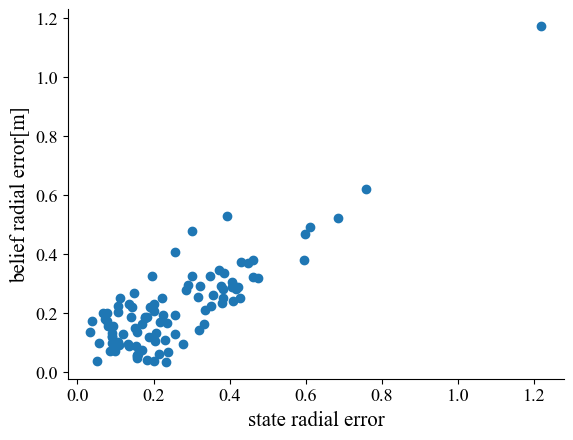

In [1233]:
plt.scatter(np.linalg.norm(statestop-truetarget, axis=1), np.linalg.norm(beliefstop-truetarget, axis=1))
plt.xlabel('state radial error')
plt.ylabel('belief radial error[m]')

In [1208]:
# i=np.random.randint(0, len(df))

# plt.plot(df.belief[i][:,0],df.belief[i][:,1], 'blue')
# plt.plot(df.state[i][:,0],df.state[i][:,1], 'red')
# circle = plt.Circle((df.task[i][0], df.task[i][1]), 0.13, color='green', fill=False)
# plt.gca().add_artist(circle)
# plt.axis('equal')


In [1209]:
# unpack the belief state
df['bmx']=df.apply(lambda x:x.belief[:,1]*worldscale*-1, axis=1)
df['bmy']=df.apply(lambda x:x.belief[:,0]*worldscale, axis=1)
df['heading']=df.apply(lambda x: x.state[:,2]*180/pi, axis=1)
df['belief_heading']=df.apply(lambda x: x.belief[:,2]*180/pi, axis=1)
# df['timer']=df.apply(lambda x: np.arange(len(x.mx)), axis=1)
# df['countdown']=df.apply(lambda x: np.flip(-np.arange(len(x.mx)), axis=0), axis=1)

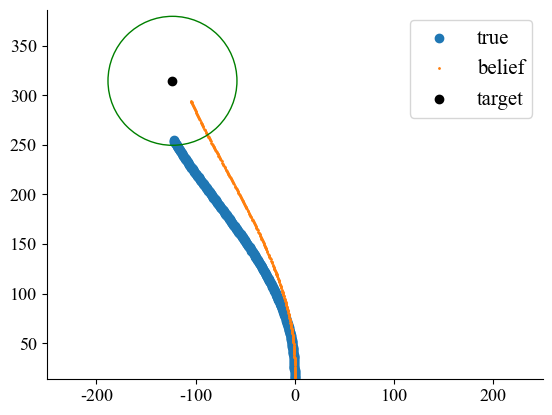

In [1210]:
i=np.random.randint(0, len(df))
trial=df.iloc[i]


plt.scatter(trial.mx, trial.my, label="true")
# plt.plot(-df.state[i][:,1]*200,df.state[i][:,0]*200, 'red', label="state")
plt.scatter(trial.bmx, trial.bmy, label="belief", s=1)
plt.scatter(trial.tar_x, trial.tar_y, c="k", label="target")
circle = plt.Circle((trial.tar_x, trial.tar_y,), 65, color='green', fill=False)
plt.gca().add_artist(circle)
plt.axis('equal')
plt.xlim([-250, 250])
plt.ylim([-20, 420])
plt.legend()

In [1211]:
# plt.plot(row.body_theta_ds*180/pi)
# plt.plot(np.cumsum(row.mw_ds)*0.1+90)
# plt.plot(row.heading+90)
# plt.show()

In [1212]:
# row=df.iloc[i]
# i+=1
# plt.plot(row.body_theta_ds)
# plt.plot(np.cumsum(row.mw_ds)+90)
# plt.show()

# plt.plot(row.heading+90)
# plt.plot(row.belief_heading+90)

In [ ]:
sessdata=defaultdict(list)

for sess in session:
    sessdf=df[df.sess_id==sess]
    states, actions, tasks = sessdf.state.to_list(), sessdf.action.to_list(),sessdf.task.to_list()
    beliefs,rawcovs=sessdf['belief'].to_list(),sessdf['rawcov'].to_list()

    sess_latentff_hori, sess_latentff_vert = [], []
    for ep_beliefs, ep_rawcovs, task in zip(beliefs, rawcovs, tasks): # process for each trial
        mx, my, body_theta,  mv, mw = zip(*ep_beliefs)
        body_theta = -(np.cumsum(mw) * 0.006-pi/2)
        body_x, body_y = np.asarray(my).reshape(-1).astype('float') * \
            worldscale, np.asarray(mx).reshape(-1).astype('float')*worldscale

        fx, fy = task[1]*worldscale, task[0]*worldscale
        rel_dist = ((fx-body_x)**2+(fy-body_y)**2)**0.5
        hor_theta_, ver_theta_ = convert_location_to_angle(abs(np.array(rel_dist)).reshape(-1).astype('float'), 
                                                           np.array(fx).reshape(-1).astype('float'), 
                                                           np.array(fy).reshape(-1).astype('float'),
                                                           body_theta.astype('float'), body_x.astype(
                                                               'float'), body_y.astype('float'),
                                                           np.array(rel_dist).reshape(-1).astype('float'), # use the true eye positions to remove pre saccade movement and after overshooting eye movement
                                                           np.array(rel_dist).reshape(-1).astype('float'), DT=0.006, 
                                                        #    remove_pre=False, remove_post=False
                                                           )
        # plt.plot(hor_theta_, ver_theta_, 'g')
        sess_latentff_hori.append(hor_theta_*-1)
        sess_latentff_vert.append(ver_theta_)
    sessdata['belief_ff_hori']+=[a.reshape(-1) for a in sess_latentff_hori]
    sessdata['belief_ff_vert']+=[a.reshape(-1) for a in sess_latentff_vert]
    

# TODO temp need change to merge
df['belief_ff_hori']=sessdata['belief_ff_hori']
df['belief_ff_vert']=sessdata['belief_ff_vert']

In [1214]:
df.columns
df.to_pickle('ruiyi_m51noradius.pkl')
!open .

In [1215]:
df.columns

Index(['monk_name', 'sess_id', 'trial_idx', 'tar_x', 'tar_y', 'tar_r',
       'tar_ang', 'error', 'error_sign', 'density', 'mx', 'my', 'mx_end',
       'my_end', 'eye_hor', 'eye_ver', 'tar_hor', 'tar_ver', 'tar_hor_withpre',
       'tar_ver_withpre', 'stop_hor', 'stop_ver', 'stop_hor_withpre',
       'stop_ver_withpre', 'eye_hor_raw', 'eye_ver_raw', 'abs_dist', 'abs_ang',
       'rel_dist', 'rel_ang', 'mx_ds', 'my_ds', 'eye_hor_ds', 'eye_ver_ds',
       'tar_hor_ds', 'tar_ver_ds', 'tar_hor_withpre_ds', 'tar_ver_withpre_ds',
       'stop_hor_ds', 'stop_ver_ds', 'stop_hor_withpre_ds',
       'stop_ver_withpre_ds', 'abs_dist_ds', 'abs_ang_ds', 'rel_dist_ds',
       'rel_ang_ds', 'eye_hor_PPC', 'tar_hor_PPC', 'stop_hor_PPC',
       'tar-eye_hor_PPC', 'stop-eye_hor_PPC', 'eye_hor_MST', 'tar_hor_MST',
       'stop_hor_MST', 'tar-eye_hor_MST', 'stop-eye_hor_MST', 'eye_hor_PFC',
       'tar_hor_PFC', 'stop_hor_PFC', 'tar-eye_hor_PFC', 'stop-eye_hor_PFC',
       'mv', 'mw', 'body_theta', 'mv_ds

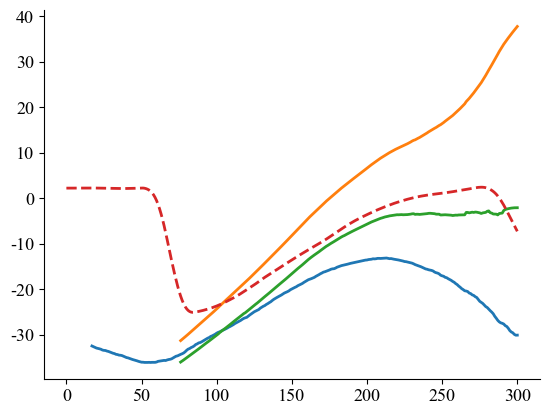

In [1230]:
i=np.random.randint(0, len(df))
plt.plot(df.belief_ff_hori[i])   
plt.plot(df.tar_hor[i])
plt.plot(df.stop_hor[i])
plt.plot(df.eye_hor[i], '--')

In [1217]:
# i=6
# plot_gradient_line(plt.gca(), -df.iloc[i].bmx, df.iloc[i].bmy, cmap_state)
# plot_gradient_line(plt.gca(), df.iloc[i].mx, df.iloc[i].my, cmap_eye)

In [1218]:
# # angle from start
# def get_angle_from_start(row):
#     return np.arctan2((np.array(row.my)), (np.array(row.mx)))

# df['angle_from_start']=df.apply(get_angle_from_start, axis=1)

# def get_belief_angle_from_start(row):
#     return np.arctan2((np.array(row.bmy)), (np.array(row.bmx)))

# df['belief_angle_from_start']=df.apply(get_angle_from_start, axis=1)


In [1219]:
# # check len
# random_rows = df.sample(n=3)

# # Iterate over the columns
# for col in random_rows.columns:
#     try:
#         # Get the column values for the selected rows
#         col_values = random_rows[col]
#         # Calculate the length of each column value
#         lengths = col_values.apply(lambda x: len(x))
#         # Print column name and the length of each column value
#         print(f"Column: {col}, Lengths: {lengths.tolist()}")
#     except: continue


In [1220]:
# # check size
# random_rows = df.sample(n=3)

# # Iterate over the columns
# for col in random_rows.columns:
#     try:
#         # Get the column values for the selected rows
#         col_values = random_rows[col]
#         # Calculate the length of each column value
#         lengths = col_values.apply(lambda x: (x.shape))
#         # Print column name and the length of each column value
#         print(f"Column: {col}, Lengths: {lengths.tolist()}")
#     except: continue

## the varialbes we have:

In [1221]:
# # state, change coord example
# trialdf=df.iloc[10]
# mx, my,mw, fx,fy=trialdf.mx, trialdf.my, trialdf.mw, trialdf.fx, trialdf.fy
# mx, my,mw, fx,fy=[np.array(a) for a in [mx, my,mw, fx,fy]]
# sx = np.ones_like(fx)
# sy = np.ones_like(fy)
# if my.size > 0:
#     fx = np.ones_like(fx) * fx[0]
#     fy = np.ones_like(fy) * fy[0]
#     sx *= mx[-1]
#     sy *= my[-1]
#     my = my + 30
#     fy = fy + 30
#     sy = sy + 30
# dx = fx - mx; dy = fy - my
# rel_dist = np.sqrt(dx**2 + dy**2); rel_ang = np.rad2deg(np.arctan2(dy, dx))
# # rel_dist_stop = np.sqrt((sx - mx)**2 + (sy - my)**2)
# # abs_dist = np.sqrt(mx**2 + my**2); abs_ang = np.rad2deg(np.arctan2(my, mx))
# heading = np.deg2rad(np.cumsum(mw*-1) * 0.1 + 90) 

# latent_ff_hori, latent_ff_vert = convert_location_to_angle(
#     rel_dist,
#     fx,
#     fy,
#     heading,
#     mx,
#     my,
#     None, # not needed if remove pre = false
#     None,
#     remove_pre=False
# )
# # plt.scatter(latent_ff_hori,trialdf.ff_hori); plt.title('state');plt.axis('equal'); plt.show()


In [1222]:
# # # belief chnage coord example
# trialdf=df.iloc[23]

# bmx, bmy, bmw, fx,fy = trialdf.bmx, trialdf.bmy, np.array(trialdf.mw), trialdf.fx, trialdf.fy
# ep_beliefs=trialdf.belief

# mx, my, body_theta,  mv, mw = zip(*ep_beliefs)
# mx, my,mw, fx,fy=[np.array(a) for a in [mx, my,mw, fx,fy]]
# mx,my=my*worldscale, mx*worldscale

# # plt.scatter(mx, bmx); plt.title('beliefmx vs bmx');plt.axis('equal'); plt.show()

# sx = np.ones_like(fx)
# sy = np.ones_like(fy)
# if my.size > 0:
#     fx = np.ones_like(fx) * fx[0]
#     fy = np.ones_like(fy) * fy[0]
#     sx *= mx[-1]
#     sy *= my[-1]
#     my = my + 30
#     fy = fy + 30
#     sy = sy + 30
# dx = fx - mx; dy = fy - my
# rel_dist = np.sqrt(dx**2 + dy**2); rel_ang = np.rad2deg(np.arctan2(dy, dx))
# # rel_dist_stop = np.sqrt((sx - mx)**2 + (sy - my)**2)
# # abs_dist = np.sqrt(mx**2 + my**2); abs_ang = np.rad2deg(np.arctan2(my, mx))

# heading2=-(np.cumsum(mw) * 0.1-pi/2)

# latent_ff_hori, latent_ff_vert = convert_location_to_angle(
#     rel_dist,
#     fx,
#     fy,
#     heading2,
#     mx,
#     my,
#     None, # not needed if remove pre = false
#     None,
#     remove_pre=False
# )
# # plt.scatter(latent_ff_hori,trialdf.belief_ff_hori); plt.title('belief');plt.axis('equal'); plt.show()


In [1223]:
# # convert belief rawcov example
# trialdf=df.iloc[23]

# bmx, bmy, bmw, fx,fy = trialdf.bmx, trialdf.bmy, np.array(trialdf.mw), trialdf.fx, trialdf.fy
# rawcov=trialdf['rawcov'][:,:2,:2]


# belief_heading=trialdf.belief_heading
# rotdegree=belief_heading+180
# relativeposrawcov=[]
# for degree, thisrawcov in zip(rotdegree, rawcov):
#     R=np.array([[np.cos(-degree/180*pi),-np.sin(-degree/180*pi)],[np.sin(-degree/180*pi),np.cos(-degree/180*pi)]])
#     relativeposrawcov.append(R.T@thisrawcov[:2,:2]@R)
# relativeposrawcov=np.stack(relativeposrawcov)
# relativeposrawcov.shape
# rotdegree

In [1224]:
# # rotate belief cov df
# def fun(trialdf):
#     if trialdf.fullon==1: # always on target, assign zero uncertainty
#         return np.ones_like(trialdf['rawcov'][:,:2,:2])*1e-6
#     cov=trialdf['rawcov'][:,:2,:2]
#     belief_heading=trialdf.belief_heading
#     rotdegree=belief_heading+180
#     relativeposcov=[]
#     for degree, thiscov in zip(rotdegree, cov):
#         R=np.array([[np.cos(-degree/180*pi),-np.sin(-degree/180*pi)],[np.sin(-degree/180*pi),np.cos(-degree/180*pi)]])
#         relativeposcov.append(R.T@thiscov[:2,:2]@R)
#     relativeposcov=np.stack(relativeposcov)*worldscale*worldscale
#     return relativeposcov
# df['relcov']=df.apply(fun, axis=1)

In [1225]:
# date='0918'
# df.to_pickle(resdir/f'{date}_m51df.pkl')
# notify(f'saved: {date}_m51df.pkl')
# print(f'saved: {date}_m51df.pkl')

In [1226]:
# # with neuron variance as PPC_var
# date='1014'
# df.to_pickle(resdir/f'{date}_m51df.pkl')
# notify(f'saved: {date}_m51df.pkl')
# print(f'saved: {date}_m51df.pkl')